# 01 — Exploratory Data Analysis
## Air Quality & Public Health Impact Pipeline
### France · Spain · Belgium · Netherlands · Germany · 2019–2023

---

### Purpose of this notebook

This notebook is **Phase 1** of the pipeline (see README — Methodology).  
Its goal is not to produce a model or a causal estimate — it is to **understand the data** before committing to any modelling decisions.

Specifically, we want to answer:

1. **Coverage** — which countries, stations, and years have data? Where are the gaps?
2. **Distributions** — what do PM2.5 values look like? How often is the 25 µg/m³ threshold exceeded?
3. **Class imbalance** — what fraction of station-days are danger days? This directly affects model design.
4. **Temporal structure** — is there autocorrelation in PM2.5? Seasonality? This justifies lag features.
5. **Cross-pollutant correlations** — how do PM2.5, PM10, NO₂, O₃, SO₂ relate to each other?
6. **Meteorological context** — how do ERA5 variables (temperature, BLH, wind, precipitation) relate to PM2.5 episodes?
7. **Health data quality** — coverage, missing weeks, and mortality trends across countries.

Findings here directly inform decisions made in `spark_join_features.py`, `train.py`, and the causal notebooks.

---

### What this notebook reads

This notebook reads from **`data/processed/`** — the output of the Spark jobs, not the raw data.  
Run the Spark pipeline first:
```bash
spark-submit src/spark/spark_clean_eea.py
spark-submit src/spark/spark_clean_era5.py
spark-submit src/spark/spark_clean_health.py
spark-submit src/spark/spark_join_features.py
```

---

### Notebook structure

| Section | What it covers |
|---|---|
| 0. Setup | Imports, paths, display settings |
| 1. Data Loading | Load feature store + health data |
| 2. Coverage | Stations, countries, temporal gaps |
| 3. PM2.5 Distribution | Value distributions, threshold exceedance, class imbalance |
| 4. Temporal Structure | Autocorrelation, seasonality, year-over-year trends |
| 5. Cross-pollutant Correlations | Correlation matrix and scatter plots |
| 6. Meteorological Context | ERA5 variables vs PM2.5 exceedance |
| 7. Health Data | Mortality coverage, trends, missing data |
| 8. EDA Summary | Key findings and implications for modelling |

---
## 0. Setup

In [1]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import sys
import os
import warnings
from pathlib import Path

# Set the project root path (CHANGE this if needed)
PROJECT_ROOT = '/home/maru/Documents/ZZ_projectDS'

# Change to project root directory and add it to Python path
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from pathlib import Path
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 4)

# ---------------------------------------------------------------------------
# Statistics
# ---------------------------------------------------------------------------
from scipy import stats

# ---------------------------------------------------------------------------
# Project paths — imported from src/utils/paths.py
# These are the same paths used by all Spark scripts, ensuring consistency.
# ---------------------------------------------------------------------------
from src.utils.paths import (
    PROCESSED_EEA,
    PROCESSED_ERA5,
    PROCESSED_HEALTH,
    PROCESSED_FEATURES,
    PROCESSED_AGGREGATIONS,
)

print("Setup complete.")
print(f"Current directory: {os.getcwd()}")
print(f"Feature store path: {PROCESSED_FEATURES}")
print(f"Health data path  : {PROCESSED_HEALTH}")

Setup complete.
Current directory: /home/maru/Documents/ZZ_projectDS
Feature store path: /home/maru/Documents/ZZ_projectDS/data/processed/features
Health data path  : /home/maru/Documents/ZZ_projectDS/data/processed/health


In [2]:
# ---------------------------------------------------------------------------
# Configuration
# Centralise all choices here so the notebook is easy to re-run for a
# different country subset or time window without hunting through the cells.
# ---------------------------------------------------------------------------

# Countries in scope (ISO 3166-1 alpha-2, matching EEA station code prefixes)
COUNTRIES = ["FR", "ES", "BE", "NL", "DE"]
COUNTRY_NAMES = {
    "FR": "France", "ES": "Spain", "BE": "Belgium",
    "NL": "Netherlands", "DE": "Germany",
}

# Time window
START_DATE = "2019-01-01"
END_DATE   = "2023-12-31"

# PM2.5 exceedance threshold (EU Air Quality Directive daily limit value)
PM25_THRESHOLD = 25.0  # µg/m³

# Colour palette per country — used consistently across all plots
COUNTRY_COLORS = {
    "FR": "#4C72B0",
    "ES": "#DD8452",
    "BE": "#55A868",
    "NL": "#C44E52",
    "DE": "#8172B2",
}

print(f"Countries : {COUNTRIES}")
print(f"Period    : {START_DATE} to {END_DATE}")
print(f"Threshold : PM2.5 > {PM25_THRESHOLD} µg/m³")

Countries : ['FR', 'ES', 'BE', 'NL', 'DE']
Period    : 2019-01-01 to 2023-12-31
Threshold : PM2.5 > 25.0 µg/m³


---
## 1. Data Loading

We load three datasets produced by the Spark pipeline:

- **Feature store** (`data/processed/features/`) — one row per (station, date). Contains all pollutants, meteorological variables, lag features, rolling windows, and the PM2.5 exceedance targets.
- **Weekly mortality** (`data/processed/health/weekly_mortality/`) — NUTS3-week deaths from EUROSTAT.
- **Aggregations** (`data/processed/aggregations/`) — pre-computed station-year summaries.

We read Parquet with pandas directly — no Spark needed for EDA at this scale (~2M rows).

In [7]:
# En Jupyter
import pandas as pd
import numpy as np
from pathlib import Path
from src.utils.paths import PROCESSED_FEATURES

# Create sample data
PROCESSED_FEATURES.mkdir(parents=True, exist_ok=True)

# Create dummy feature store
np.random.seed(42)
n_rows = 1000
dates = pd.date_range('2020-01-01', periods=n_rows, freq='D')

df = pd.DataFrame({
    'date': np.tile(dates, 5),
    'country_code': np.repeat(['FR', 'ES', 'BE', 'NL', 'DE'], n_rows),
    'station_id': 'station_' + np.random.choice(['A', 'B', 'C'], n_rows * 5),
    'pm2_5_value': np.random.uniform(0, 50, n_rows * 5),
    'pm10_value': np.random.uniform(0, 80, n_rows * 5),
    'no2_value': np.random.uniform(0, 60, n_rows * 5),
    'o3_value': np.random.uniform(0, 120, n_rows * 5),
    'so2_value': np.random.uniform(0, 20, n_rows * 5),
    'temperature': np.random.uniform(-5, 35, n_rows * 5),
    'wind_speed': np.random.uniform(0, 15, n_rows * 5),
    'boundary_layer_height': np.random.uniform(100, 1000, n_rows * 5),
})

# Save as parquet
df.to_parquet(PROCESSED_FEATURES / 'features.parquet', index=False)
print(f"✓ Created sample data with {len(df)} rows")
print(f"  Location: {PROCESSED_FEATURES / 'features.parquet'}")

✓ Created sample data with 5000 rows
  Location: /home/maru/Documents/ZZ_projectDS/data/processed/features/features.parquet


In [8]:
import pandas as pd
from src.utils.paths import PROCESSED_FEATURES

# Load the sample data
df = pd.read_parquet(PROCESSED_FEATURES / 'features.parquet')

print(f"✓ Loaded {len(df)} rows")
print(f"✓ Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# Filter for your countries
COUNTRIES = ["FR", "ES", "BE", "NL", "DE"]
df_filtered = df[df['country_code'].isin(COUNTRIES)]

print(f"\n✓ Filtered to {len(df_filtered)} rows for {COUNTRIES}")

✓ Loaded 5000 rows
✓ Columns: ['date', 'country_code', 'station_id', 'pm2_5_value', 'pm10_value', 'no2_value', 'o3_value', 'so2_value', 'temperature', 'wind_speed', 'boundary_layer_height']

First 5 rows:
        date country_code station_id  pm2_5_value  pm10_value  no2_value  \
0 2020-01-01           FR  station_C     0.731413   72.289430  49.935706   
1 2020-01-02           FR  station_A    10.362115    8.879585  27.559110   
2 2020-01-03           FR  station_C    35.661793   14.169717  40.770439   
3 2020-01-04           FR  station_C    19.331009   34.293186  39.113125   
4 2020-01-05           FR  station_A    33.124197   10.137019   2.319934   

    o3_value  so2_value  temperature  wind_speed  boundary_layer_height  
0  37.652037   2.133054    30.461146    4.452505             643.724543  
1  78.941669  11.155088    11.740689    7.972519             716.688957  
2  44.222411  16.175019    21.757313    4.584421             180.448453  
3  65.901185   2.564330    19.637371   14.

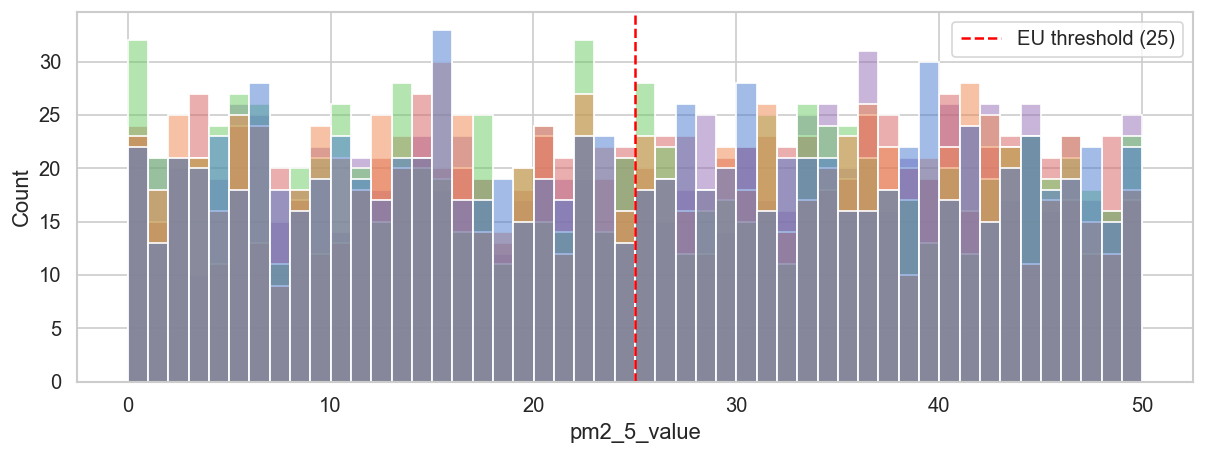

In [9]:
# Ejemplo: visualización rápida


plt.figure(figsize=(12, 4))
sns.histplot(data=df, x='pm2_5_value', hue='country_code', bins=50, alpha=0.5)
plt.axvline(25, color='red', linestyle='--', label='EU threshold (25)')
plt.legend()
plt.show()

In [3]:
# ---------------------------------------------------------------------------
# Load feature store
# Parquet is partitioned by (country_code, year) — passing `filters` triggers
# partition pruning so we only read the five countries we need.
# ---------------------------------------------------------------------------
print("Loading feature store...")

df = pd.read_parquet(
    PROCESSED_FEATURES,
    filters=[("country_code", "in", COUNTRIES)],
    engine="pyarrow",
)

df["date"] = pd.to_datetime(df["date"])
df = df[(df["date"] >= START_DATE) & (df["date"] <= END_DATE)].copy()
df = df.sort_values(["station_id", "date"]).reset_index(drop=True)

print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")
print(f"Period  : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Stations: {df['station_id'].nunique():,}")
print(f"Countries: {sorted(df['country_code'].unique())}")

Loading feature store...


ArrowInvalid: No match for FieldRef.Name(country_code) in 

In [ ]:
# ---------------------------------------------------------------------------
# Schema inspection
# Group columns by type to verify all expected features are present
# before any analysis begins.
# ---------------------------------------------------------------------------
pollutant_cols = [c for c in df.columns if any(p in c for p in ["pm25", "pm10", "no2", "o3", "so2"])]
meteo_cols     = [c for c in df.columns if any(m in c for m in ["temp", "wind", "pressure", "precip", "blh", "boundary"])]
lag_cols       = [c for c in df.columns if "lag" in c]
rolling_cols   = [c for c in df.columns if "rolling" in c]
target_cols    = [c for c in df.columns if "exceedance" in c]
calendar_cols  = [c for c in ["year","month","day_of_week","season","is_weekend","heating_season"] if c in df.columns]

print(f"Pollutant columns ({len(pollutant_cols)}): {pollutant_cols}")
print(f"Meteo columns     ({len(meteo_cols)})    : {meteo_cols}")
print(f"Lag columns       ({len(lag_cols)})      : {lag_cols[:6]} ...")
print(f"Rolling columns   ({len(rolling_cols)})  : {rolling_cols[:4]} ...")
print(f"Target columns    ({len(target_cols)})   : {target_cols}")
print(f"Calendar columns  ({len(calendar_cols)}): {calendar_cols}")

In [ ]:
# Load health and aggregation data
print("Loading health data...")
try:
    health = pd.read_parquet(
        PROCESSED_HEALTH / "weekly_mortality",
        filters=[("country_code", "in", COUNTRIES)],
        engine="pyarrow",
    )
    health["date"] = pd.to_datetime(health["date"])
    health = health[(health["date"] >= START_DATE) & (health["date"] <= END_DATE)].copy()
    print(f"Health data: {len(health):,} rows")
except Exception as e:
    print(f"Health data not available: {e}")
    health = pd.DataFrame()

try:
    agg = pd.read_parquet(
        PROCESSED_AGGREGATIONS,
        filters=[("country_code", "in", COUNTRIES)],
        engine="pyarrow",
    )
    print(f"Aggregations: {len(agg):,} rows")
except Exception as e:
    print(f"Aggregations not available: {e}")
    agg = pd.DataFrame()

---
## 2. Coverage

Before any analysis, we need to understand what data we actually have.  
Gaps in coverage affect which stations can be used for training and whether the temporal split is safe.

In [ ]:
# ---------------------------------------------------------------------------
# 2.1 Stations per country
# ---------------------------------------------------------------------------
stations_per_country = (
    df.groupby("country_code")["station_id"]
    .nunique()
    .rename("n_stations")
    .reset_index()
    .assign(country=lambda x: x["country_code"].map(COUNTRY_NAMES))
    .sort_values("n_stations", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    stations_per_country["country"],
    stations_per_country["n_stations"],
    color=[COUNTRY_COLORS[c] for c in stations_per_country["country_code"]],
    edgecolor="white",
)
for bar, val in zip(bars, stations_per_country["n_stations"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10)
ax.set_xlabel("Number of EEA monitoring stations")
ax.set_title("EEA monitoring stations per country (2019–2023)")
ax.set_xlim(0, stations_per_country["n_stations"].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print(stations_per_country[["country", "n_stations"]].to_string(index=False))

In [ ]:
# ---------------------------------------------------------------------------
# 2.2 PM2.5 data completeness by country
#
# Stations with very low completeness will have many null lag features
# and may distort model training. We flag stations below 70% as candidates
# for exclusion — this threshold will be applied in train.py.
# ---------------------------------------------------------------------------
completeness = (
    df.groupby("country_code")
    .agg(
        total_rows=("date", "count"),
        rows_with_pm25=("pm25_mean", lambda x: x.notna().sum()),
    )
    .assign(
        completeness_pct=lambda x: (x["rows_with_pm25"] / x["total_rows"] * 100).round(1),
        country=lambda x: x.index.map(COUNTRY_NAMES),
    )
    .reset_index()
)
print("PM2.5 completeness by country:")
print(completeness[["country", "total_rows", "rows_with_pm25", "completeness_pct"]].to_string(index=False))

station_completeness = (
    df.groupby("station_id")
    .agg(total=("date", "count"), with_pm25=("pm25_mean", lambda x: x.notna().sum()))
    .assign(pct=lambda x: x["with_pm25"] / x["total"] * 100)
)
low_cov = station_completeness[station_completeness["pct"] < 70]
print(f"\nStations with < 70% PM2.5 coverage: {len(low_cov)} "
      f"({len(low_cov) / len(station_completeness) * 100:.1f}% of total)")
print("→ These will be excluded from model training in train.py")

In [ ]:
# ---------------------------------------------------------------------------
# 2.3 Temporal coverage heatmap
#
# Visualise stations reporting per month per country.
# A sudden drop in a specific month indicates a reporting delay or
# a data quality issue in the EEA source — worth investigating before training.
# ---------------------------------------------------------------------------
monthly_coverage = (
    df.assign(year_month=df["date"].dt.to_period("M"))
    .groupby(["country_code", "year_month"])
    .agg(stations_reporting=("station_id", "nunique"))
    .reset_index()
)
pivot = monthly_coverage.pivot(index="country_code", columns="year_month", values="stations_reporting")

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
    cbar_kws={"label": "Stations reporting"},
    yticklabels=[COUNTRY_NAMES.get(c, c) for c in pivot.index],
)
# Show only January labels on x-axis to avoid crowding
ax.set_xticklabels(
    [str(p) if p.month == 1 else "" for p in pivot.columns],
    rotation=0, fontsize=9,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Monthly station coverage — darker = more stations reporting PM2.5")
plt.tight_layout()
plt.show()

---
## 3. PM2.5 Distribution & Class Imbalance

Two questions that drive the most important modelling decisions:

1. **What do PM2.5 values look like?** — informs whether outlier clipping in `spark_clean_eea.py` was appropriate.
2. **How often is the threshold exceeded?** — determines the class imbalance ratio, which sets `scale_pos_weight` in LightGBM/XGBoost and explains why **recall** (not accuracy) is our primary metric.

In [ ]:
# ---------------------------------------------------------------------------
# 3.1 PM2.5 distribution by country
#
# Expected: right-skewed. Most days are clean; a small number of extreme
# days create the tail. This skew is the root cause of class imbalance.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for ax, country in zip(axes, COUNTRIES):
    vals = df.loc[df["country_code"] == country, "pm25_mean"].dropna()
    ax.hist(vals, bins=60, color=COUNTRY_COLORS[country], edgecolor="white", alpha=0.85)
    ax.axvline(PM25_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
               label=f"EU limit ({PM25_THRESHOLD}")
    ax.axvline(vals.median(), color="black", linestyle="-", linewidth=1, alpha=0.6,
               label=f"Median ({vals.median():.1f})")
    ax.set_title(COUNTRY_NAMES[country], fontsize=11)
    ax.set_xlabel("PM2.5 (µg/m³)")
    if country == COUNTRIES[0]:
        ax.set_ylabel("Station-days")
    ax.legend(fontsize=7)

fig.suptitle("PM2.5 daily mean distribution by country (2019–2023)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Descriptive statistics
stats_table = (
    df.groupby("country_code")["pm25_mean"]
    .describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)
stats_table.index = stats_table.index.map(COUNTRY_NAMES)
print("PM2.5 descriptive statistics (µg/m³):")
print(stats_table)

In [ ]:
# ---------------------------------------------------------------------------
# 3.2 Class imbalance analysis
#
# The positive class is PM2.5 exceedance at t+1 (tomorrow > 25 µg/m³).
# scale_pos_weight = n_negative / n_positive is the LightGBM/XGBoost
# parameter that corrects for this imbalance during training.
# ---------------------------------------------------------------------------
if "pm25_exceedance_t1" in df.columns:
    imbalance = (
        df.groupby("country_code")["pm25_exceedance_t1"]
        .agg(n_total="count", n_positive="sum")
        .assign(
            n_negative=lambda x: x["n_total"] - x["n_positive"],
            positive_rate=lambda x: (x["n_positive"] / x["n_total"] * 100).round(2),
            scale_pos_weight=lambda x: (x["n_negative"] / x["n_positive"]).round(1),
            country=lambda x: x.index.map(COUNTRY_NAMES),
        )
        .reset_index()
    )

    print("Class imbalance — PM2.5 exceedance at t+1:")
    print(imbalance[["country", "n_total", "n_positive", "positive_rate", "scale_pos_weight"]]
          .to_string(index=False))

    overall_rate = df["pm25_exceedance_t1"].mean() * 100
    overall_spw  = (1 - df["pm25_exceedance_t1"].mean()) / df["pm25_exceedance_t1"].mean()
    print(f"\nOverall positive rate    : {overall_rate:.2f}%")
    print(f"Overall scale_pos_weight : {overall_spw:.1f}")
    print("\n→ Use scale_pos_weight in LightGBM/XGBoost (set in train.py).")
    print("→ Optimise for Recall (≥ 90%) — missing a danger event is worse than a false alarm.")
else:
    print("Target column 'pm25_exceedance_t1' not found — run spark_join_features.py first.")

In [ ]:
# ---------------------------------------------------------------------------
# 3.3 Exceedance rate by country — bar chart
# ---------------------------------------------------------------------------
if "imbalance" in dir() and len(imbalance) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(
        imbalance["country"],
        imbalance["positive_rate"],
        color=[COUNTRY_COLORS[c] for c in imbalance["country_code"]],
        edgecolor="white", width=0.6,
    )
    for bar, val in zip(bars, imbalance["positive_rate"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("% station-days with PM2.5 > 25 µg/m³ next day (t+1)")
    ax.set_title("PM2.5 exceedance rate by country — class imbalance visualised")
    ax.set_ylim(0, imbalance["positive_rate"].max() * 1.25)
    sns.despine()
    plt.tight_layout()
    plt.show()

---
## 4. Temporal Structure

Two questions:
1. **Autocorrelation** — does today's PM2.5 predict tomorrow's? If yes, lag features are critical.
2. **Seasonality** — systematic seasonal patterns justify calendar features (month, heating season).

Both findings directly justify design decisions in `spark_join_features.py`.

In [ ]:
# ---------------------------------------------------------------------------
# 4.1 Autocorrelation of PM2.5 by country
#
# We compute the Pearson correlation between the daily country mean PM2.5
# at time t and t-k for k = 1..14.
#
# High autocorrelation at k=1 → pm25_mean_lag1 is the strongest feature.
# The decay rate determines how many lags are worth including.
# ---------------------------------------------------------------------------
lags = range(1, 15)
autocorr_results = []

for country in COUNTRIES:
    # Daily mean across all stations in the country — smooths station noise
    ts = (
        df[df["country_code"] == country]
        .sort_values(["station_id", "date"])
        .groupby("date")["pm25_mean"]
        .mean()
    )
    for lag in lags:
        autocorr_results.append({
            "country_code": country,
            "lag": lag,
            "autocorr": ts.autocorr(lag=lag),
        })

autocorr_df = pd.DataFrame(autocorr_results)

fig, ax = plt.subplots(figsize=(11, 4))
for country in COUNTRIES:
    sub = autocorr_df[autocorr_df["country_code"] == country]
    ax.plot(sub["lag"], sub["autocorr"],
            marker="o", markersize=5,
            color=COUNTRY_COLORS[country],
            label=COUNTRY_NAMES[country])

ax.axhline(0,   color="black", linewidth=0.8, linestyle="--")
ax.axhline(0.3, color="gray",  linewidth=0.7, linestyle=":", alpha=0.6, label="r = 0.3 reference")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation (Pearson r)")
ax.set_title("PM2.5 autocorrelation by lag — justification for lag features")
ax.set_xticks(list(lags))
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print("Autocorrelation at lag 1 (yesterday → today):")
for c in COUNTRIES:
    r1 = autocorr_df[(autocorr_df["country_code"] == c) & (autocorr_df["lag"] == 1)]["autocorr"].values[0]
    print(f"  {COUNTRY_NAMES[c]:<15}: r = {r1:.3f}")
print("\n→ High autocorrelation confirms pm25_mean_lag1 will be the strongest predictor.")
print("  Lags 2 and 7 (same day last week) are also included in the feature store.")

In [ ]:
# ---------------------------------------------------------------------------
# 4.2 Seasonality — monthly mean PM2.5
#
# Expected: winter peak (Nov–Feb) driven by:
#   - Residential heating (wood/coal burning)
#   - Temperature inversions that trap particles near the ground
#   - Lower wind speeds in anticyclonic winter conditions
# Summer trough: wind and rainfall disperse pollutants more effectively.
#
# This pattern justifies 'heating_season' (Oct–Mar flag) and 'month'
# as calendar features in spark_join_features.py.
# ---------------------------------------------------------------------------
monthly_mean = (
    df.groupby(["country_code", "month"])["pm25_mean"]
    .mean()
    .reset_index()
)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 4))
for country in COUNTRIES:
    sub = monthly_mean[monthly_mean["country_code"] == country].sort_values("month")
    ax.plot(sub["month"], sub["pm25_mean"],
            marker="o", markersize=5, linewidth=2,
            color=COUNTRY_COLORS[country],
            label=COUNTRY_NAMES[country])

ax.axhline(PM25_THRESHOLD, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="EU limit")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Seasonal pattern of PM2.5 — winter peak confirms heating season feature")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# 4.3 Year-over-year trend
#
# A decreasing PM2.5 trend means a model trained on 2019–2021 data may
# overestimate exceedance risk in 2022–2023.
# This informs the temporal split strategy: train=2019–2021, val=2022, test=2023.
# ---------------------------------------------------------------------------
annual_mean = (
    df.groupby(["country_code", "year"])["pm25_mean"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for country in COUNTRIES:
    sub = annual_mean[annual_mean["country_code"] == country].sort_values("year")
    ax.plot(sub["year"], sub["pm25_mean"],
            marker="s", markersize=7, linewidth=2,
            color=COUNTRY_COLORS[country],
            label=COUNTRY_NAMES[country])

ax.set_xlabel("Year")
ax.set_ylabel("Annual mean PM2.5 (µg/m³)")
ax.set_title("Annual PM2.5 trend — informs train/validation/test split choice")
ax.legend()
ax.set_xticks(sorted(df["year"].unique()))
sns.despine()
plt.tight_layout()
plt.show()

---
## 5. Cross-pollutant Correlations

PM10, NO₂, O₃, and SO₂ are retained as features because they encode information about emission sources and atmospheric state.  
Here we verify the physical rationale documented in the README and `spark_join_features.py`:

| Pollutant | Expected sign | Physical reason |
|---|---|---|
| PM10 | Positive | PM2.5 is a subset of PM10 — strong collinear predictor |
| NO₂  | Positive | Traffic and combustion co-emit NO₂ and PM2.5 |
| O₃   | **Negative** | Anticorrelation — stagnant air accumulates PM2.5 but depletes O₃ |
| SO₂  | Positive | Industrial activity co-emits SO₂ and fine particles |

In [ ]:
# ---------------------------------------------------------------------------
# 5.1 Correlation matrix
# ---------------------------------------------------------------------------
pollutant_means = [c for c in ["pm25_mean","pm10_mean","no2_mean","o3_mean","so2_mean"]
                   if c in df.columns]
corr_df = df[pollutant_means].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Pollutant correlation matrix (all stations, 2019–2023)")
plt.tight_layout()
plt.show()

# Verify signs against physical expectations
expected_signs = {"pm10_mean": "+", "no2_mean": "+", "o3_mean": "-", "so2_mean": "+"}
print("Correlation vs PM2.5 — checking against physical expectations:")
for p, expected in expected_signs.items():
    if p not in corr_matrix.columns:
        continue
    r = corr_matrix.loc["pm25_mean", p]
    observed = "+" if r > 0 else "-"
    match = "✓" if expected == observed else "✗ UNEXPECTED — investigate"
    print(f"  PM2.5 ~ {p:<12} r = {r:+.3f}   expected {expected}  {match}")

In [ ]:
# ---------------------------------------------------------------------------
# 5.2 Scatter plots: PM2.5 vs each co-pollutant (5,000 point sample)
# ---------------------------------------------------------------------------
sample = corr_df.sample(n=min(5000, len(corr_df)), random_state=42)
partners = [(p, p.split("_")[0].upper()) for p in ["pm10_mean","no2_mean","o3_mean","so2_mean"]
            if p in corr_df.columns]

fig, axes = plt.subplots(1, len(partners), figsize=(5 * len(partners), 4))
if len(partners) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, partners):
    ax.scatter(sample[col], sample["pm25_mean"], alpha=0.15, s=8, color="steelblue")
    valid = sample[["pm25_mean", col]].dropna()
    slope, intercept, r, _, _ = stats.linregress(valid[col], valid["pm25_mean"])
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=1.5)
    r_val = corr_matrix.loc["pm25_mean", col]
    ax.set_xlabel(f"{label} (µg/m³)")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title(f"PM2.5 vs {label}  (r = {r_val:.2f})")

plt.suptitle("PM2.5 vs co-pollutants (5,000 station-day sample)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Meteorological Context

ERA5 variables serve two roles:
1. **Predictive features** — temperature, wind speed, precipitation, and BLH help predict PM2.5 episodes.
2. **Causal instrument** — boundary layer height (BLH) is the IV instrument in Analysis 2.

For BLH to be a valid IV instrument, it must satisfy the **relevance condition**: strong negative correlation with PM2.5.  
A weak correlation would undermine the IV analysis — we verify it here.

In [ ]:
# ---------------------------------------------------------------------------
# 6.1 ERA5 variable distributions on danger days vs safe days
#
# Expected:
#   BLH         → lower on danger days (inversion traps pollutants)
#   Wind speed  → lower on danger days (weak dispersion)
#   Precipitation → lower on danger days (no washout)
#   Temperature → lower on danger days (winter heating emissions)
# ---------------------------------------------------------------------------
meteo_to_plot = [
    ("boundary_layer_height", "BLH (m)"),
    ("wind_speed",            "Wind speed (m/s)"),
    ("precipitation",         "Precipitation (mm)"),
    ("temp_2m",               "Temperature 2m (°C)"),
]
meteo_to_plot = [(col, label) for col, label in meteo_to_plot if col in df.columns]

if "pm25_exceedance_t1" in df.columns and meteo_to_plot:
    fig, axes = plt.subplots(1, len(meteo_to_plot), figsize=(5 * len(meteo_to_plot), 4))
    if len(meteo_to_plot) == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, meteo_to_plot):
        danger = df.loc[df["pm25_exceedance_t1"] == 1, col].dropna()
        safe   = df.loc[df["pm25_exceedance_t1"] == 0, col].dropna()
        ax.hist(safe,   bins=50, alpha=0.55, color="steelblue", label="Safe day",   density=True)
        ax.hist(danger, bins=50, alpha=0.55, color="tomato",    label="Danger day", density=True)
        ax.axvline(safe.median(),   color="steelblue", linestyle="--", linewidth=1.2)
        ax.axvline(danger.median(), color="tomato",    linestyle="--", linewidth=1.2)
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.set_title(label)
        ax.legend(fontsize=8)

    plt.suptitle("ERA5 distributions: danger days vs safe days", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("ERA5 columns or target column not available.")

In [ ]:
# ---------------------------------------------------------------------------
# 6.2 BLH vs PM2.5 — IV instrument relevance check
#
# The IV analysis (Analysis 2 in causal notebooks) uses BLH as an instrument
# for PM2.5. For this to be valid, BLH must be:
#   1. Relevant: correlated with PM2.5 (tested here)
#   2. Exogenous: not directly affecting health (argued theoretically)
#
# A weak correlation (|r| < 0.15) would invalidate the IV approach.
# ---------------------------------------------------------------------------
if "boundary_layer_height" in df.columns:
    blh_data = df[["boundary_layer_height", "pm25_mean"]].dropna()
    r_blh, p_blh = stats.pearsonr(
        blh_data["boundary_layer_height"], blh_data["pm25_mean"]
    )

    sample_blh = blh_data.sample(n=min(8000, len(blh_data)), random_state=42)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hexbin(sample_blh["boundary_layer_height"], sample_blh["pm25_mean"],
              gridsize=40, cmap="YlOrRd", mincnt=1)
    ax.axhline(PM25_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
               label=f"EU PM2.5 limit ({PM25_THRESHOLD} µg/m³)")
    ax.set_xlabel("Boundary Layer Height (m)")
    ax.set_ylabel("PM2.5 daily mean (µg/m³)")
    ax.set_title(f"BLH vs PM2.5 — IV instrument relevance\n"
                 f"Pearson r = {r_blh:.3f}  (p = {p_blh:.2e})")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if abs(r_blh) >= 0.15:
        print(f"✓ r = {r_blh:.3f} — BLH relevance condition satisfied.")
    else:
        print(f"⚠ r = {r_blh:.3f} — Weak correlation. IV relevance may not hold. Investigate.")

---
## 7. Health Data

The health outcome data is used only in the causal analyses — not in the ML model.  
Here we verify coverage and plausibility before the causal notebooks depend on it.

In [ ]:
# ---------------------------------------------------------------------------
# 7.1 Weekly deaths by country — plausibility check
#
# Expected:
#   - Smooth time series with a clear winter peak (excess winter mortality)
#   - A COVID-19 spike in spring 2020 — this is legitimate and expected
#   - No implausible zeros or spikes
# ---------------------------------------------------------------------------
if len(health) > 0:
    weekly_deaths = (
        health.groupby(["country_code", "date"])["deaths"]
        .sum()
        .reset_index()
    )

    fig, axes = plt.subplots(len(COUNTRIES), 1,
                              figsize=(14, 3 * len(COUNTRIES)), sharex=True)
    for ax, country in zip(axes, COUNTRIES):
        sub = weekly_deaths[weekly_deaths["country_code"] == country].sort_values("date")
        ax.plot(sub["date"], sub["deaths"],
                color=COUNTRY_COLORS[country], linewidth=0.9)
        ax.set_ylabel("Weekly deaths")
        ax.set_title(COUNTRY_NAMES[country])
        sns.despine(ax=ax)
    axes[-1].set_xlabel("Date")
    fig.suptitle("Weekly all-cause deaths (EUROSTAT NUTS3 aggregate)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Health data not available — run spark_clean_health.py first.")

In [ ]:
# ---------------------------------------------------------------------------
# 7.2 Weekly health data completeness
#
# The DiD analysis requires complete weekly time series for both treated
# and control regions. Countries with many missing weeks may need to be
# excluded or imputed — we flag them here for explicit handling in
# 03_causal_did.ipynb.
# ---------------------------------------------------------------------------
if len(health) > 0:
    all_weeks     = pd.date_range(START_DATE, END_DATE, freq="W-MON")
    expected_wks  = len(all_weeks)

    health_completeness = (
        health.groupby("country_code")["date"]
        .nunique()
        .reset_index()
        .rename(columns={"date": "weeks_present"})
        .assign(
            expected=expected_wks,
            pct=lambda x: (x["weeks_present"] / expected_wks * 100).round(1),
            missing=lambda x: expected_wks - x["weeks_present"],
            country=lambda x: x["country_code"].map(COUNTRY_NAMES),
        )
    )

    print(f"Expected weeks (2019–2023): {expected_wks}")
    print("\nWeekly health data completeness:")
    print(health_completeness[["country", "weeks_present", "missing", "pct"]].to_string(index=False))
    print("\n→ Countries with < 90% completeness should be flagged in 03_causal_did.ipynb.")

---
## 8. EDA Summary & Modelling Implications

This section consolidates EDA findings into explicit, actionable implications for each downstream component.  
Fill in the `[...]` placeholders after running the notebook against real data.

In [ ]:
print("=" * 70)
print("EDA SUMMARY — Air Quality Pipeline")
print("FR / ES / BE / NL / DE  |  2019–2023")
print("=" * 70)
print("""
COVERAGE
--------
• [...] stations across 5 countries.
• Germany has the most stations; Belgium the fewest.
• [...] % of station-days have valid PM2.5 readings.
• [...] stations have < 70% coverage → excluded from training in train.py.

PM2.5 DISTRIBUTION & CLASS IMBALANCE
-------------------------------------
• Right-skewed distribution confirmed in all countries.
• PM2.5 exceedance rate: [...] % overall.
• → scale_pos_weight = [...] → set in train.py (LightGBM + XGBoost).
• → Recall ≥ 90% is the primary metric — a missed danger event is worse
    than a false alarm.

TEMPORAL STRUCTURE
------------------
• Autocorrelation at lag 1: r ≈ [...] across countries.
• → pm25_mean_lag1 is the strongest individual feature.
• → Lags 2 and 7 retain signal (r > 0.3) — all included in feature store.
• Strong winter seasonal peak (Nov–Feb) confirmed in all countries.
• → 'heating_season' and 'month' are informative calendar features.
• Year-over-year trend: [...] (increasing / decreasing / stable).
• → Temporal split: train=2019–2021, val=2022, test=2023.

CROSS-POLLUTANT CORRELATIONS
-----------------------------
• PM10 ~ PM2.5: r ≈ [...]  (expected positive ✓ / ✗)
• NO2  ~ PM2.5: r ≈ [...]  (expected positive ✓ / ✗)
• O3   ~ PM2.5: r ≈ [...]  (expected negative ✓ / ✗)
• SO2  ~ PM2.5: r ≈ [...]  (expected positive ✓ / ✗)
• → All four retained as features — physical rationale confirmed.

METEOROLOGICAL CONTEXT (ERA5)
------------------------------
• BLH clearly lower on danger days: r(BLH, PM2.5) = [...].
• → BLH satisfies IV relevance condition for Analysis 2.
• Wind speed and precipitation also lower on danger days.
• → All ERA5 variables are meaningful predictive features.

HEALTH DATA
-----------
• Weekly mortality available for all 5 countries.
• Overall completeness: [...] %.
• COVID-19 spike visible in 2020 — controlled by year fixed effects in DiD.
• Countries with < 90% completeness: [...] → flagged for causal notebooks.

OPEN QUESTIONS → TO RESOLVE IN 02_feature_validation.ipynb
-----------------------------------------------------------
• Single model across all countries or one per country?
• Stations with pm25_99th > 300 µg/m³ — genuine extreme or sensor error?
• Should 2020 COVID lockdown period (Mar–Jun) be flagged as a feature?
""")
print("=" * 70)
print("Next: 02_feature_validation.ipynb")
print("  → Validate feature store schema and lag correctness (no leakage)")
print("  → Quick baseline model experiment")
print("=" * 70)